In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("churn_data.csv")
df.columns = df.columns.str.strip().str.lower()

# Convert + clean
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
df = df.fillna(0)

# Drop ID
df.drop('customerid', axis=1, inplace=True)

# Encoding
df['churn'] = df['churn'].map({'Yes':1, 'No':0})
df = pd.get_dummies(df, drop_first=True)

In [3]:
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ==============================
# CLEAN DATA PROPERLY
# ==============================

# Fix column names
df.columns = df.columns.str.strip().str.lower()

# Convert totalcharges
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# Fill missing values
df = df.fillna(0)

# Drop ID
if 'customerid' in df.columns:
    df.drop('customerid', axis=1, inplace=True)

# Convert target (VERY IMPORTANT)
df['churn'] = df['churn'].map({'Yes':1, 'No':0})

# Convert all categorical → numeric
df = pd.get_dummies(df, drop_first=True)

# ==============================
# SPLIT DATA
# ==============================
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data ready for model")

✅ Data ready for model


In [ ]:
print(df['churn'].unique())

[nan]


In [ ]:
print(df['churn'].unique())

[nan]


In [ ]:
df = df.dropna(subset=['churn'])

In [ ]:
df['churn'] = df['churn'].map({'Yes':1, 'No':0})

In [ ]:
print(X_train.dtypes)
print(X_train.isnull().sum().sum())
print(y_train.unique())

tenure                            int64
monthlycharges                    int64
totalcharges                      int64
seniorcitizen                     int64
contract_one year                  bool
contract_two year                  bool
paymentmethod_credit card          bool
paymentmethod_electronic check     bool
paperlessbilling_yes               bool
dtype: object
0
[nan]


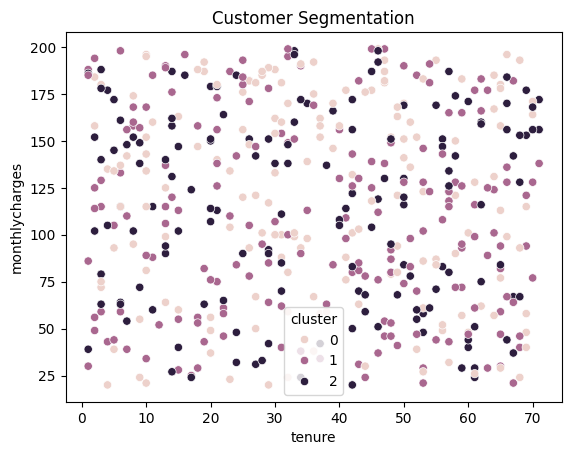

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

sns.scatterplot(x='tenure', y='monthlycharges', hue='cluster', data=df)
plt.title("Customer Segmentation")
plt.show()

Columns: Index(['customerid', 'tenure', 'monthlycharges', 'totalcharges', 'contract',
       'paymentmethod', 'paperlessbilling', 'seniorcitizen', 'churn'],
      dtype='str')
Churn values: [0 1]

🌳 Decision Tree Results
Accuracy: 0.95

🌲 Random Forest Results
Accuracy: 0.96
Precision: 0.9285714285714286
Recall: 0.8125
F1 Score: 0.8666666666666667

Confusion Matrix:
 [[83  1]
 [ 3 13]]

Best Parameters: {'max_depth': 10, 'n_estimators': 100}

Top Features:
 tenure                            0.606750
monthlycharges                    0.130214
totalcharges                      0.114633
contract_One year                 0.056115
contract_Two year                 0.032817
seniorcitizen                     0.016971
paperlessbilling_Yes              0.016672
paymentmethod_Electronic Check    0.013398
paymentmethod_Credit Card         0.012431
dtype: float64


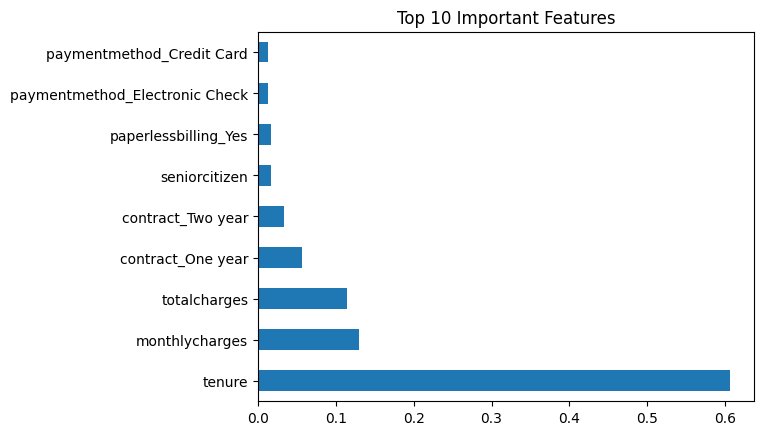

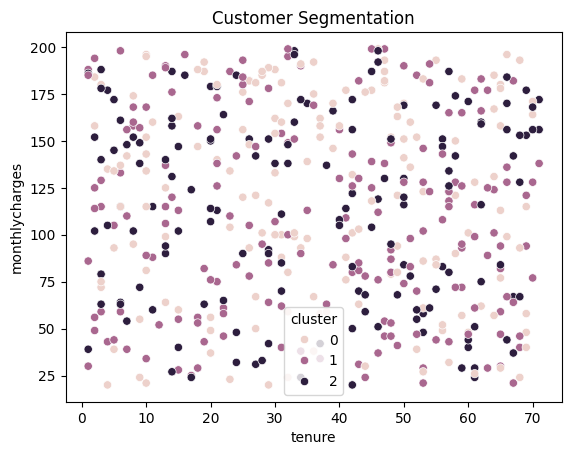


🎯 WEEK 11 PROJECT COMPLETED SUCCESSFULLY ✅


In [4]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("churn_data.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)

# ==============================
# 3. FIX DATA ISSUES
# ==============================

# Convert totalcharges
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# Fill missing values
df = df.fillna(0)

# Drop customerid if exists
if 'customerid' in df.columns:
    df.drop('customerid', axis=1, inplace=True)

# 🔥 FIX CHURN COLUMN (SAFE WAY)
if df['churn'].dtype == 'object':
    df['churn'] = df['churn'].astype(str).str.strip().str.lower()
    df['churn'] = df['churn'].map({'yes':1, 'no':0})

# If still NaN → fill
df['churn'] = df['churn'].fillna(0).astype(int)

print("Churn values:", df['churn'].unique())

# ==============================
# 4. ENCODING
# ==============================
df = pd.get_dummies(df, drop_first=True)

# ==============================
# 5. SPLIT DATA
# ==============================
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 6. DECISION TREE
# ==============================
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\n🌳 Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

# ==============================
# 7. RANDOM FOREST
# ==============================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n🌲 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# ==============================
# 8. HYPERPARAMETER TUNING
# ==============================
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# ==============================
# 9. FEATURE IMPORTANCE
# ==============================
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop Features:\n", importance.head(10))

plt.figure()
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

# ==============================
# 10. CLUSTERING
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters

plt.figure()
sns.scatterplot(x=df['tenure'], y=df['monthlycharges'], hue=df['cluster'])
plt.title("Customer Segmentation")
plt.show()

# ==============================
# 11. SAVE FILES
# ==============================
df.to_csv("final_churn_data.csv", index=False)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})
results.to_csv("predictions_week11.csv", index=False)
print("\n🎯 WEEK 11 PROJECT COMPLETED SUCCESSFULLY ✅")

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
})

results.to_csv("model_evaluation_results.csv", index=False)

print("✅ Evaluation file saved")



✅ Evaluation file saved
